### Force between two conductors using Maxwell stress tensor. 
#### This uses same setup than "notebooks/A_field_wire.ipynb",  but now multiple conductors experience forces.

Lorentz force acts F=ILB  for each conductor,  where B is the constant B field from the other wire.

This eq adds the B-field produced from another wire for two windings: $\frac{F}{L} = \frac{\mu_0I_1I_2}{2 \pi r}$

where L is the length of wires and r is their disntace

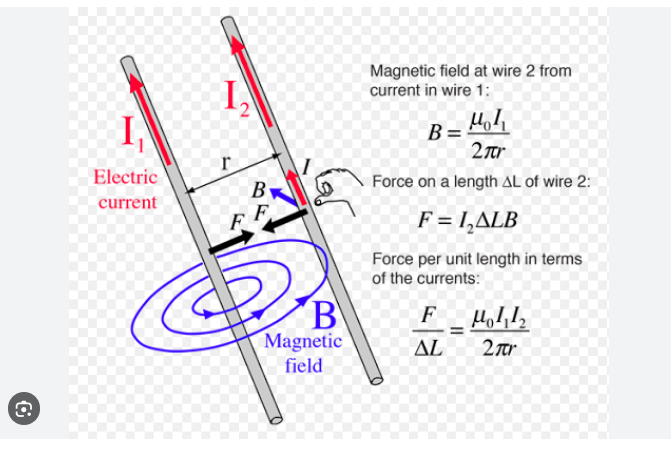

Our fem models is easy to verify with this example, since it is simple



Lets solve:
I1 = 100A
I2 = -50A
L  =  5m
mu = mu0
r = 0.6 m   // wires are 0.05 radius, so their midpoints are 0.6+0.05+0.05 = 0.7m apart

this gives,  F/L = 0.001666617512 N/m        
force is repelling, since current flows different direcitons. 

Lets make geometry for this using gmsh. We use "meshes/wire.ipynb" as a base.

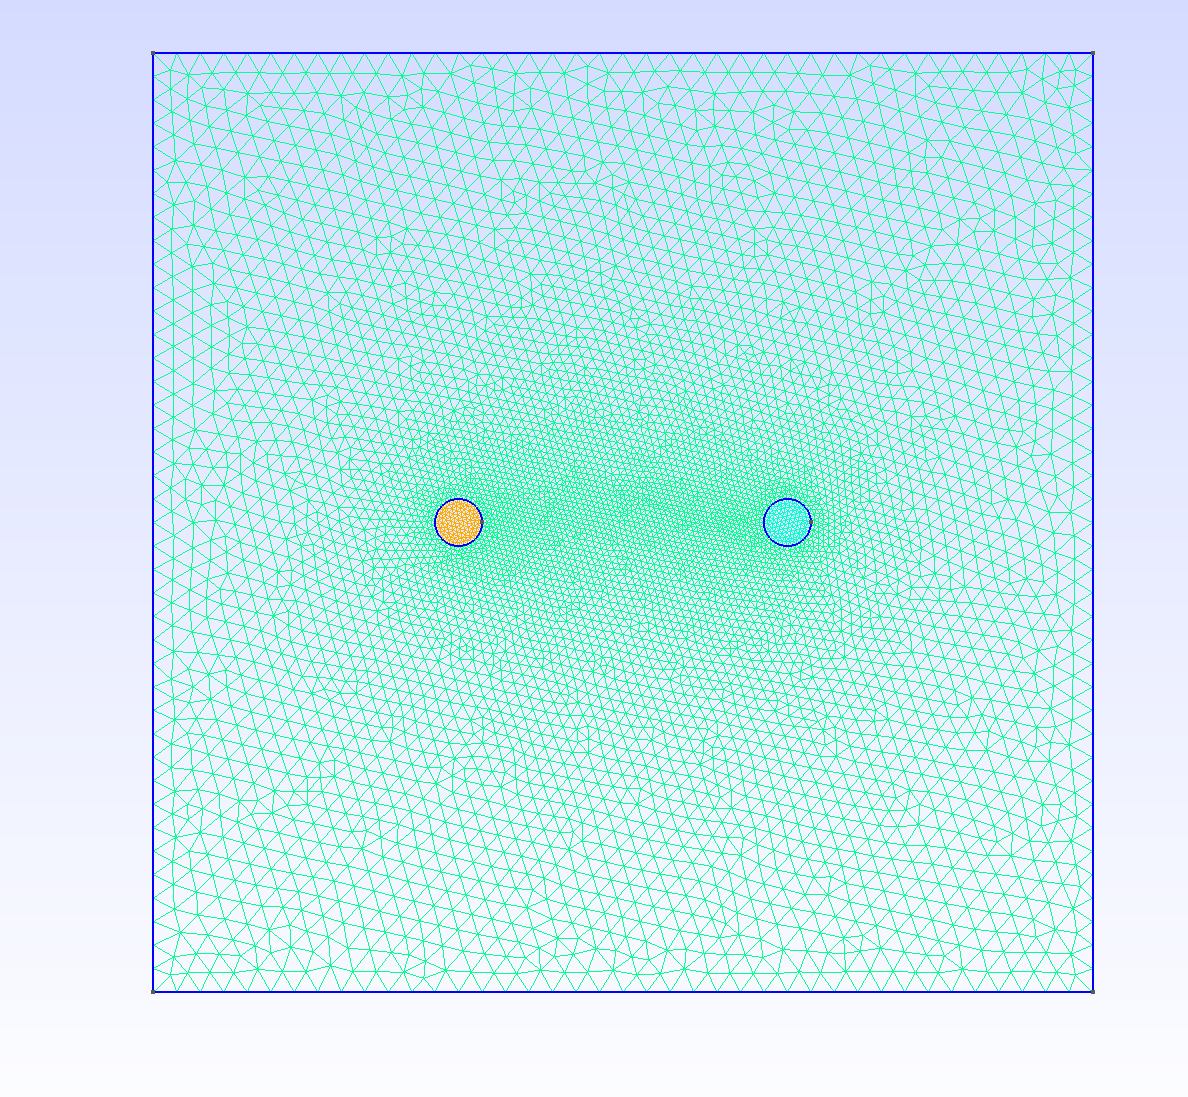


Let's solve A field  ->  B-field -> Force using maxwell stress tensor


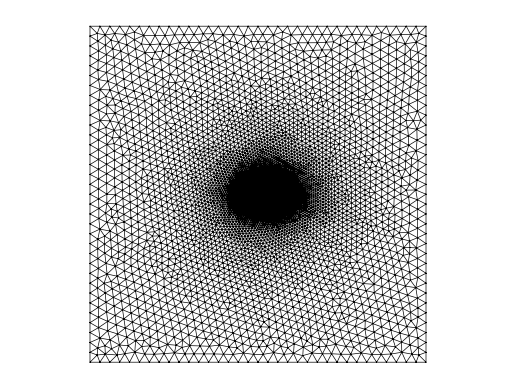

In [96]:
import meshio
from skfem import *
from skfem.helpers import dot, grad
import numpy as np

from skfem.io.meshio import from_meshio

m = meshio.read("../meshes/wire_force_contour.msh")

mesh = from_meshio(m)

from skfem.visuals.matplotlib import draw
import matplotlib.pyplot as plt

draw(mesh)
plt.axis("equal")
plt.show()

We are solving Amperes law, and material law

\begin{equation} \nabla \times \mathbf{H} = \mathbf{J} \end{equation}

\begin{equation} \mathbf{B} = \mu \mathbf{H} \end{equation}

Our problems setup is:

<!-- \begin{equation} -\nabla \cdot \left( \frac{1}{\mu} \nabla A_z \right) = J_z. \end{equation} \quad  \in \Omega -->

\begin{equation*} - \nabla \cdot \left( \frac{1}{\mu} \nabla A_z \right) = J_z  \quad  \in \Omega_{conductors}  \end{equation*} 

\begin{equation*} - \nabla \cdot \left( \frac{1}{\mu} \nabla A_z \right) = 0  \quad  \in \Omega_{air}  \end{equation*}

\begin{equation*}  A_z = 0 \quad \in \partial \Omega  \end{equation*}


Linear basis functions for each domain. Az is easy to solve with these

In [103]:
e = ElementTriP1()
basis = Basis(mesh, e)

basis_air = basis.with_elements(mesh.subdomains["air"])
basis_shell = basis.with_elements(mesh.subdomains["shell1"])
basis_wire1 = basis.with_elements(mesh.subdomains["wire1"])
basis_wire2 = basis.with_elements(mesh.subdomains["wire2"])


basis_f = FacetBasis(
    mesh,
    e,
    facets=mesh.boundaries["force_boundary"],
)

#fbasis = FacetBasis(
#    mesh,
#    e,
#    facets=mesh.boundaries["force_boundary"],
#    side=1,
#)

print(basis_wire1)
print(basis_wire2)
print(basis_air)
print(basis_shell)

<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 212
  Number of DOFs: 16184
  Size: 45792 B
<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 212
  Number of DOFs: 16184
  Size: 45792 B
<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 20102
  Number of DOFs: 16184
  Size: 4342032 B
<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 11704
  Number of DOFs: 16184
  Size: 2528064 B


In [104]:
# Small debug/test  that geometry works:

# Test winding area
from skfem import Functional
@Functional
def area(w):
    return 1.0

area_wire1 = area.assemble(basis_wire1)
area_wire2 = area.assemble(basis_wire2)
area_shell = area.assemble(basis_shell)

# should be area = 0.007853981634

print("Win area1: ", area_wire1)
print("Win area2: ", area_wire2)
print("area shell: ", area_shell)

Win area1:  0.007803612880645115
Win area2:  0.0078036128806451156
area shell:  0.49479913255890406


In [109]:

# w.mu little coonfusing but it just wraps the permeability to some variable w
@BilinearForm
def laplace(A, v, w):
    return 1/w.mu*dot(grad(A), grad(v))


@LinearForm
def rhs(v, w):
    return w.J * v


mu0 = 4 * np.pi * 1e-7
mu_air = mu0
mu_wire = mu0

S = laplace.assemble(basis_air, mu=mu0)
S += laplace.assemble(basis_shell, mu=mu0)
S += laplace.assemble(basis_wire1, mu=mu0)
S += laplace.assemble(basis_wire2, mu=mu0)


# Wire 1
I_1 = 100 # Amperes
J_wire_1 = I_1/area_wire1
print("J1 =  ", J_wire_1)

# Wire 2
I_2 = -50 # Amperes
J_wire_2 = I_2/area_wire2
print("J2 =  ", J_wire_2)



b = rhs.assemble(basis_air, J=0.0)
b += rhs.assemble(basis_shell, J=0.0)
b += rhs.assemble(basis_wire1, J=J_wire_1)
b += rhs.assemble(basis_wire2, J=J_wire_2)


J1 =   12814.577238707558
J2 =   -6407.288619353778


Add Dirichelt BC Az=0 to all boundaries. This models the air as infinitely large volume.

enforce() does the zero BC by default

In [110]:
boundary_dofs = basis.get_dofs("boundary")
S, b = enforce(S, b, D=boundary_dofs)


Solve and visualize Az

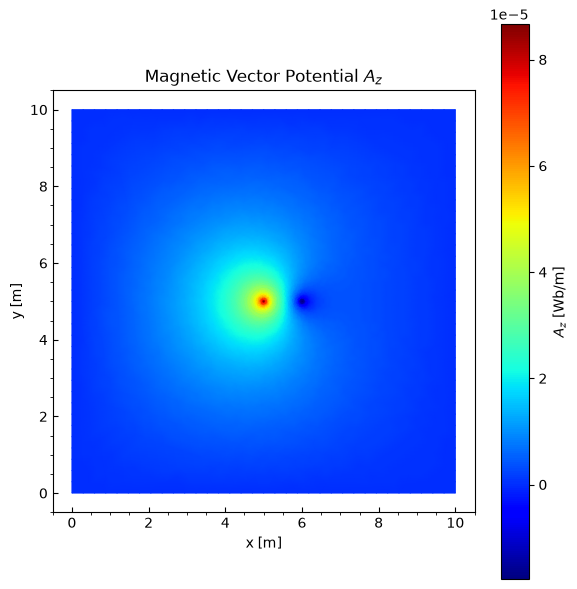

In [111]:
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot

A_z = solve(S, b)

def visualize():
    fig, ax = plt.subplots(figsize=(6, 6))

    plot(
        mesh,
        A_z,
        ax=ax,
        shading='gouraud',
        colorbar=True
    )

    ax.set_title(r"Magnetic Vector Potential $A_z$")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")

    # Show coordinate ticks
    ax.tick_params(direction='in')
    ax.minorticks_on()

    # Label the colorbar
    cbar = fig.axes[-1]
    cbar.set_ylabel(r"$A_z$ [Wb/m]")

    fig.tight_layout()

if __name__ == "__main__":
    visualize()
    plt.show()

Next, we compute B field from our A field solution. We use the partial derivatives that connect A and B

We switch from plotting nodal values, to plotting element-wise values. With B field they behave nicely.


In [ ]:
# basis.interpolate(A_z) creates a finite element function Ah = sum(Ni*Ai)   ,  where Ni is shape function and Ai is nodal vectorpotential values

# Interpolate A_z on the *facet* basis (not the interior basis!)
uh_f = basis_f.interpolate(A_z)


# grad object has the dA/dx and dA/dy components
dAz_dx = uh_f.grad[0]
dAz_dy = uh_f.grad[1]

Bx =  dAz_dy
By = -dAz_dx
B2 = Bx**2 + By**2

Txx = (Bx**2 - 0.5 * B2) / mu0
Tyy = (By**2 - 0.5 * B2) / mu0
Txy = (Bx * By) / mu0

# outward normals at each quadrature point on the facets
nx, ny = basis_f.normals

tx = Txx * nx + Txy * ny
ty = Txy * nx + Tyy * ny

# integrate: basis.dx already contains quadrature weight * |detJ|
Fx = (tx * basis_f.dx).sum()
Fy = (ty * basis_f.dx).sum()

print(Fx, Fy)

# --------------------------------------------------
# Analytical reference (infinite parallel line currents)
# --------------------------------------------------

# Gmsh vars
L = 10.0

r = 0.05
r_force = 0.40

cx = L / 2
cy = L / 2

# second wire: placed outside the force contour, along +x
d = 1.0          # center-to-center distance, must be > r_force + r2 + margin
r2 = 0.05
cx2 = cx + 2*d
cy2 = cy


mu0 = 4 * np.pi * 1e-7

d = cx2 - cx   # center-to-center distance, from your gmsh geometry variables

Fx_analytical = mu0 * I_1 * I_2 / (2 * np.pi * d)
Fy_analytical = 0.0

# --------------------------------------------------
# FEM result (from your stress tensor integration)
# --------------------------------------------------

Fx_fem = Fx   # however you named your integrated result
Fy_fem = Fy

# --------------------------------------------------
# Comparison
# --------------------------------------------------

rel_err_x = abs(Fx_fem - Fx_analytical) / abs(Fx_analytical)

# Fy has no nonzero reference, so just report absolute value
# scaled against the Fx magnitude for context
abs_err_y_scaled = abs(Fy_fem) / abs(Fx_analytical)

print("=" * 55)
print(f"{'':20s}{'Fx':>15s}{'Fy':>15s}")
print(f"{'FEM':20s}{Fx_fem:15.6e}{Fy_fem:15.6e}")
print(f"{'Analytical':20s}{Fx_analytical:15.6e}{Fy_analytical:15.6e}")
print("-" * 55)
print(f"Relative error in Fx:       {rel_err_x:.4%}")
print(f"|Fy| / |Fx_analytical|:     {abs_err_y_scaled:.4%}  (should be ~0)")
print("=" * 55)

if rel_err_x < 0.05:
    print("PASS: Fx within 5% of analytical line-current approximation.")
else:
    print("CHECK: Fx deviates more than 5% — check mesh refinement, "
          "contour placement, sign convention, or mu.")

"""
from skfem import Functional
import numpy as np
r = 0.05
r_force = 0.10
l = 5 # axial length?
prefactor = l / (mu0 * (r_force - r))

@Functional
def arkkio(w):
    x = w.x[0]
    y = w.x[1]

    rr = np.sqrt(x**2 + y**2)

    Br = (x*w.Bx + y*w.By) / rr
    Bt = (-y*w.Bx + x*w.By) / rr

    return prefactor * Br * Bt * rr

shell_elements = mesh.subdomains["shell1"]
Bx_shell = Bx[shell_elements]
By_shell = By[shell_elements]

T = arkkio.assemble(
    basis_shell,
    Bx=Bx_shell,
    By=By_shell,
)

print("Troque: ", T)
"""

-0.0009776490324894817 4.437143862105969e-07
                                 Fx             Fy
FEM                   -9.776490e-04   4.437144e-07
Analytical            -1.000000e-03   0.000000e+00
-------------------------------------------------------
Relative error in Fx:       2.2351%
|Fy| / |Fx_analytical|:     0.0444%  (should be ~0)
PASS: Fx within 5% of analytical line-current approximation.


'\nfrom skfem import Functional\nimport numpy as np\nr = 0.05\nr_force = 0.10\nl = 5 # axial length?\nprefactor = l / (mu0 * (r_force - r))\n\n@Functional\ndef arkkio(w):\n    x = w.x[0]\n    y = w.x[1]\n\n    rr = np.sqrt(x**2 + y**2)\n\n    Br = (x*w.Bx + y*w.By) / rr\n    Bt = (-y*w.Bx + x*w.By) / rr\n\n    return prefactor * Br * Bt * rr\n\nshell_elements = mesh.subdomains["shell1"]\nBx_shell = Bx[shell_elements]\nBy_shell = By[shell_elements]\n\nT = arkkio.assemble(\n    basis_shell,\n    Bx=Bx_shell,\n    By=By_shell,\n)\n\nprint("Troque: ", T)\n'

(2, 1863)
(3, 3644)
(2, 3, 3644)
(2, 3644)


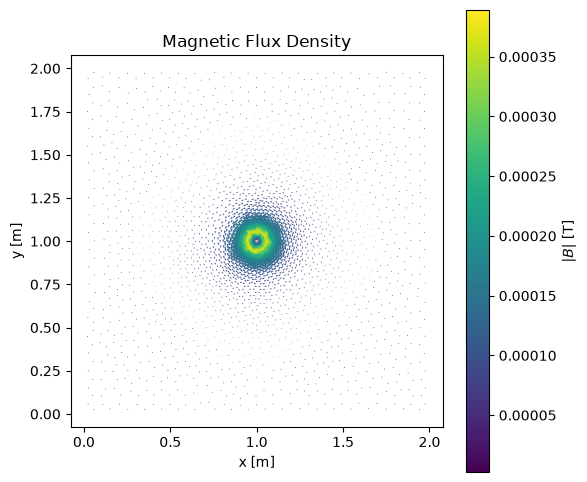

In [13]:
# Plot

centers = mesh.p[:, mesh.t].mean(axis=2)

print(mesh.p.shape)
print(mesh.t.shape)

print(mesh.p[:, mesh.t].shape)
centers = mesh.p[:, mesh.t].mean(axis=1)
print(centers.shape)

fig, ax = plt.subplots(figsize=(6, 6))

q = ax.quiver(
    centers[0],
    centers[1],
    Bx_elem,
    By_elem,
    np.sqrt(Bx_elem**2 + By_elem**2),   # color arrows by |B|
    cmap="viridis"
)

ax.set_title("Magnetic Flux Density")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal")

fig.colorbar(q, ax=ax, label=r"$|B|$ [T]")

plt.show()

Magnitude of B

Number of air elements: 11484
Min |B| in air : 7.016635e-07 T
Max |B| in air : 3.918244e-04 T
Mean |B| in air: 5.120565e-05 T


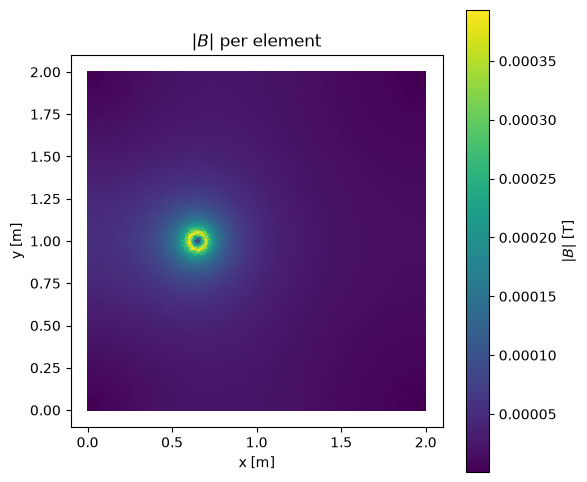

In [ ]:
Bnorm_elem = np.sqrt(Bx_elem**2 + By_elem**2)


# Element indices belonging to the air region
air_elems = basis_air.tind

print(f"Number of air elements: {len(air_elems)}")

B_air = Bnorm_elem[air_elems]

print(f"Min |B| in air : {B_air.min():.6e} T")
print(f"Max |B| in air : {B_air.max():.6e} T")
print(f"Mean |B| in air: {B_air.mean():.6e} T")

import matplotlib.tri as mtri

tri = mtri.Triangulation(
    mesh.p[0],
    mesh.p[1],
    mesh.t.T
)

fig, ax = plt.subplots(figsize=(6,6))

pc = ax.tripcolor(
    tri,
    facecolors=Bnorm_elem,
    edgecolors='none',
    cmap='viridis'
)

ax.set_title(r"$|B|$ per element")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal")

fig.colorbar(pc, ax=ax, label=r"$|B|$ [T]")

plt.show()

Now with the element-wise B we can compute the force acting between windings.  Newton laws: the yare same but opposite.

We do this with maxwell stress tensor. In 2D, it will looks like this for our case.

\begin{equation} \mathbf{T} = \frac{1}{\mu_0} \begin{bmatrix} \dfrac{1}{2}\left(B_x^2 - B_y^2\right) & B_x B_y \\[6pt] B_x B_y & \dfrac{1}{2}\left(B_y^2 - B_x^2\right) \end{bmatrix} \end{equation}


The theory says that if we integrate closed loop in 2d with this tensor, we get force that acts on the body

\begin{equation} \mathbf{F} = \oint_{\Gamma} \mathbf{T}\,\mathbf{n}\,d\Gamma \end{equation}

Nex we define rectangular contour/path that goes around the wire. This will be our integration path. Lets go around wire 1



In [ ]:

def rectangular_contour(cx, cy, half, N):

    xmin = cx-half
    xmax = cx+half

    ymin = cy-half
    ymax = cy+half

    bottom = np.column_stack([
        np.linspace(xmin, xmax, N),
        np.full(N, ymin)
    ])

    right = np.column_stack([
        np.full(N, xmax),
        np.linspace(ymin, ymax, N)
    ])

    top = np.column_stack([
        np.linspace(xmax, xmin, N),
        np.full(N, ymax)
    ])

    left = np.column_stack([
        np.full(N, xmin),
        np.linspace(ymax, ymin, N)
    ])

    return bottom, right, top, left


# --------------------------------------------------
# Contour parameters
# --------------------------------------------------

r = 0.05               # wire radius
L = 2.0                 # air box
distance = 0.70         # center-to-center spacing
cx = L / 2
cy = L / 2
x1 = cx - distance / 2
x2 = cx + distance / 2

N = 500

offset = 0.05
half = r + offset

bottom, right, top, left = rectangular_contour(
    x1,
    cy,
    6*r,
    N
)


Lets plot our contour

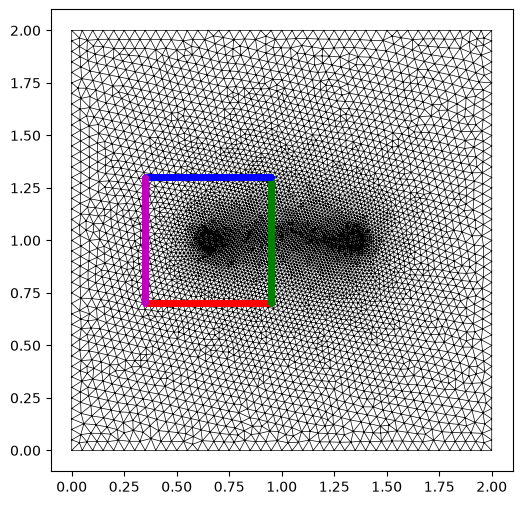

In [ ]:
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import draw

fig, ax = plt.subplots(figsize=(6,6))

draw(mesh, ax=ax)

ax.plot(bottom[:,0], bottom[:,1], 'r.')
ax.plot(right[:,0], right[:,1], 'g.')
ax.plot(top[:,0], top[:,1], 'b.')
ax.plot(left[:,0], left[:,1], 'm.')

ax.set_aspect("equal")

plt.show()

Looks as expected!

Lets perform integration

In [ ]:
# Function we use
def integrate_edge(points, normal):

    # init zeros
    Fx = 0.0
    Fy = 0.0

    # given as input
    normal = np.asarray(normal)
    finder = mesh.element_finder()
    for i in range(len(points)-1):

        # midpoint of segment
        midpoint = 0.5*(points[i] + points[i+1])

        # L = sum(ds) but probably wont be that heavy to run it here as well...
        ds = np.linalg.norm(points[i+1]-points[i])

        x, y = midpoint

        # Which triangle contains this point?
       
        elem = finder(np.array([x]), np.array([y]))[0]

        Bx = Bx_elem[elem]
        By = By_elem[elem]
        

        B2 = Bx**2 + By**2

        # Build Maxwell stress tensor
        T = np.array([
            [(Bx*Bx-0.5*B2)/mu0, Bx*By/mu0],
            [Bx*By/mu0, (By*By-0.5*B2)/mu0]
        ])

    
        traction = T @ normal

        Fx += traction[0] * ds
        Fy += traction[1] * ds


    return Fx, Fy

Fx = 0.0
Fy = 0.0

# Bottom
fx, fy = integrate_edge(bottom, (0, -1))
Fx += fx
Fy += fy

# Right
fx, fy = integrate_edge(right, (1, 0))
Fx += fx
Fy += fy

# Top
fx, fy = integrate_edge(top, (0, 1))
Fx += fx
Fy += fy

# Left
fx, fy = integrate_edge(left, (-1, 0))
Fx += fx
Fy += fy

print(f"Fx/L = {Fx:.8e} N/m")
print(f"Fy/L = {Fy:.8e} N/m")
print(f"|F|/L = {np.sqrt(Fx**2 + Fy**2):.8e} N/m")


Fx/L = 7.36287405e-04 N/m
Fy/L = -2.71047572e-06 N/m
|F|/L = 7.36292394e-04 N/m


The force is alot in x directions -> good as the wire should push away not attract. The minus sign is expected.
Lets comapre with the analytical equation

$\frac{F}{L} = \frac{\mu_0I_1I_2}{2 \pi r}$



In [ ]:
# distance between wires
dist = 0.6

Fx_analytical = mu0*I_1*I_2/(2*np.pi*dist)
print("Analytical F_x per length acting wire 1: ", Fx_analytical)

Analytical F_x per length acting wire 1:  -0.0016666666666666668
